# Factor AI Lab 03 — when does physics help a neural network?

This notebook compares the **same neural-network architecture** trained three ways:

1. **Data-only NN:** match sparse, noisy velocity measurements.
2. **PINN with the generating equation:** match the data and a simplified motion equation.
3. **PINN with a wrong equation:** match the same data while enforcing an incorrect drive history.

This is a teaching benchmark, not a validated liner model. It begins *after* PDV has produced velocity-like measurements. It does not infer melting, ETI, MRTI, or mechanism.

## Explain it like I am five
A normal neural network draws a smooth line through the dots we measured. A physics-informed neural network gets an extra rule: its line should also move the way our equation says an object moves. A good rule can guide the line through missing data. A wrong rule can confidently bend the line the wrong way.

## Frozen teaching contract
- **Question:** Can an assumed motion equation improve reconstruction between sparse velocity observations?
- **Allowed data:** 18 noisy velocity samples, initial position, and normalized time.
- **Output:** continuous inward position and velocity.
- **Truth:** a separate numerical solution of the toy equation.
- **Primary metric:** dense-grid velocity MAE, reported overall and inside an unobserved time gap.
- **Comparison budget:** identical architecture and optimizer; only the loss changes.
- **Failure control:** repeat the PINN with a deliberately mistimed and weakened drive.
- **Prohibited claim:** success here does not validate this equation for a real liner or validate PDV reconstruction.

In [1]:
import copy, platform, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
from scipy.integrate import solve_ivp

torch.manual_seed(7)
np.random.seed(7)
torch.set_num_threads(1)
DEVICE = torch.device('cpu')  # higher derivatives are small and dependable on CPU
DTYPE = torch.float32
VELOCITY_SCALE = 1000.0  # m/s per dimensionless velocity unit
sns.set_theme(style='whitegrid', context='notebook')
print(f'Python {platform.python_version()} | PyTorch {torch.__version__} | device {DEVICE}')

Python 3.12.14 | PyTorch 2.14.0 | device cpu


## 1. A transparent toy motion equation
Let `x(τ)` be normalized inward displacement and `u = dx/dτ`. We generate truth from

`d²x/dτ² = α p(τ)² / (1 - βx) - γ dx/dτ`.

The squared pulse loosely resembles magnetic-pressure scaling with current squared; the radius factor and damping are illustrative. These terms omit material strength, resistive diffusion, phase change, plasma coupling, geometry evolution, and multidimensional instability.

In [2]:
TRUE = {'alpha': 1.45, 'beta': 0.28, 'gamma': 0.38, 'shift': 0.0}
WRONG = {'alpha': 0.90, 'beta': 0.28, 'gamma': 0.38, 'shift': 0.11}

def pulse_numpy(t, shift=0.0):
    z = np.clip((t-shift)/0.86, 0, 1)
    return np.sin(np.pi*z)**2

def rhs(t, state, pars):
    x, u = state
    drive = pars['alpha']*pulse_numpy(t, pars['shift'])**2/(1-pars['beta']*x)
    return [u, drive-pars['gamma']*u]

t_dense = np.linspace(0, 1, 301)
solution = solve_ivp(lambda t,y: rhs(t,y,TRUE), (0,1), [0,0], t_eval=t_dense, rtol=1e-10, atol=1e-12)
x_truth, u_truth = solution.y
v_truth = VELOCITY_SCALE*u_truth

# Sparse observations deliberately leave a hole during rapid acceleration.
candidate = np.r_[np.linspace(.04,.39,10), np.linspace(.68,.96,8)]
measure_t = np.unique(np.round(candidate, 5))
measure_v_true = np.interp(measure_t, t_dense, v_truth)
rng = np.random.default_rng(42)
NOISE_STD = 22.0
measure_v = measure_v_true + rng.normal(0, NOISE_STD, len(measure_t))
print(f'{len(measure_t)} observations; no measurements from 0.39 to 0.68; noise σ={NOISE_STD:.0f} m/s')

18 observations; no measurements from 0.39 to 0.68; noise σ=22 m/s


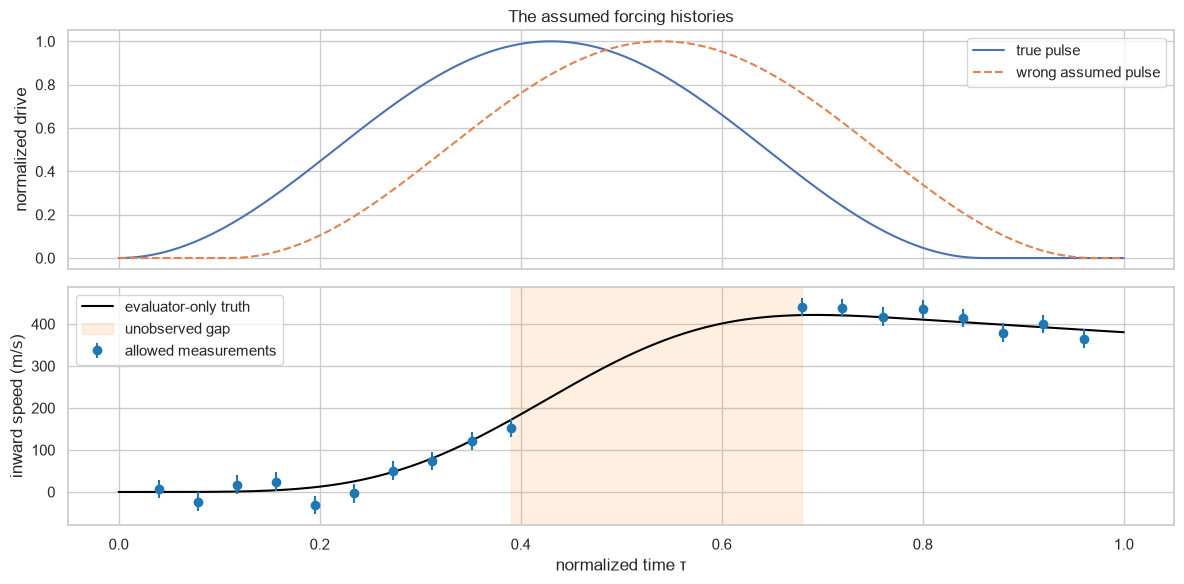

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12,6), sharex=True)
axes[0].plot(t_dense, pulse_numpy(t_dense), label='true pulse')
axes[0].plot(t_dense, pulse_numpy(t_dense, WRONG['shift']), '--', label='wrong assumed pulse')
axes[0].set(ylabel='normalized drive', title='The assumed forcing histories'); axes[0].legend()
axes[1].plot(t_dense, v_truth, color='black', label='evaluator-only truth')
axes[1].errorbar(measure_t, measure_v, yerr=NOISE_STD, fmt='o', color='tab:blue', label='allowed measurements')
axes[1].axvspan(.39,.68,color='tab:orange',alpha=.12,label='unobserved gap')
axes[1].set(xlabel='normalized time τ',ylabel='inward speed (m/s)'); axes[1].legend()
plt.tight_layout(); plt.show()

## 2. One architecture, three training objectives
This is a fully connected neural network, also called an MLP. Every time coordinate passes through three hidden layers of 64 neurons. `Tanh` is used because PINNs need smooth first and second derivatives. PyTorch automatic differentiation supplies velocity and acceleration from the predicted position.

In [4]:
class TrajectoryNet(nn.Module):
    def __init__(self, width=64):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(1,width), nn.Tanh(),
            nn.Linear(width,width), nn.Tanh(),
            nn.Linear(width,width), nn.Tanh(),
            nn.Linear(width,1))
    def forward(self, t):
        # Multiplication by t exactly enforces x(0)=0.
        return t*self.layers(t)

def derivatives(model, t, create_graph=True):
    t = t.clone().detach().requires_grad_(True)
    x = model(t)
    u = torch.autograd.grad(x, t, torch.ones_like(x), create_graph=True)[0]
    a = torch.autograd.grad(u, t, torch.ones_like(u), create_graph=create_graph)[0]
    return x, u, a

probe = TrajectoryNet()
print(probe)
print('Trainable parameters:', sum(p.numel() for p in probe.parameters()))

TrajectoryNet(
  (layers): Sequential(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)
Trainable parameters: 8513


In [5]:
def pulse_torch(t, shift):
    z = torch.clamp((t-shift)/.86, 0, 1)
    return torch.sin(torch.pi*z)**2

t_obs = torch.tensor(measure_t[:,None],dtype=DTYPE,device=DEVICE)
u_obs = torch.tensor((measure_v/VELOCITY_SCALE)[:,None],dtype=DTYPE,device=DEVICE)
t_physics = torch.linspace(0,1,161,device=DEVICE,dtype=DTYPE)[:,None]

def train(label, physics_weight, pars, epochs=2200):
    torch.manual_seed(123)  # same initialization for every comparison
    model = TrajectoryNet().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(),lr=1.5e-3)
    history=[]; best={'loss':float('inf'),'state':None}
    for epoch in range(1,epochs+1):
        optimizer.zero_grad()
        _, u_at_data, _ = derivatives(model,t_obs)
        data_loss=((u_at_data-u_obs)**2).mean()
        x,u,a=derivatives(model,t_physics)
        drive=pars['alpha']*pulse_torch(t_physics,pars['shift'])**2/(1-pars['beta']*x)
        residual=a-drive+pars['gamma']*u
        physics_loss=(residual**2).mean()
        initial_velocity=u[0].square().mean()
        loss=data_loss+physics_weight*physics_loss+initial_velocity
        loss.backward(); optimizer.step()
        if loss.item()<best['loss']:
            best={'loss':loss.item(),'state':copy.deepcopy(model.state_dict())}
        if epoch==1 or epoch%50==0:
            history.append({'epoch':epoch,'total':loss.item(),'data':data_loss.item(),'physics':physics_loss.item()})
    model.load_state_dict(best['state']); model.eval()
    return {'label':label,'model':model,'history':pd.DataFrame(history)}

started=time.perf_counter()
runs=[train('Data-only NN',0.0,TRUE), train('PINN: correct toy equation',1.0,TRUE), train('PINN: wrong toy equation',1.0,WRONG)]
print(f'Trained three models in {time.perf_counter()-started:.1f} s')

Trained three models in 8.6 s


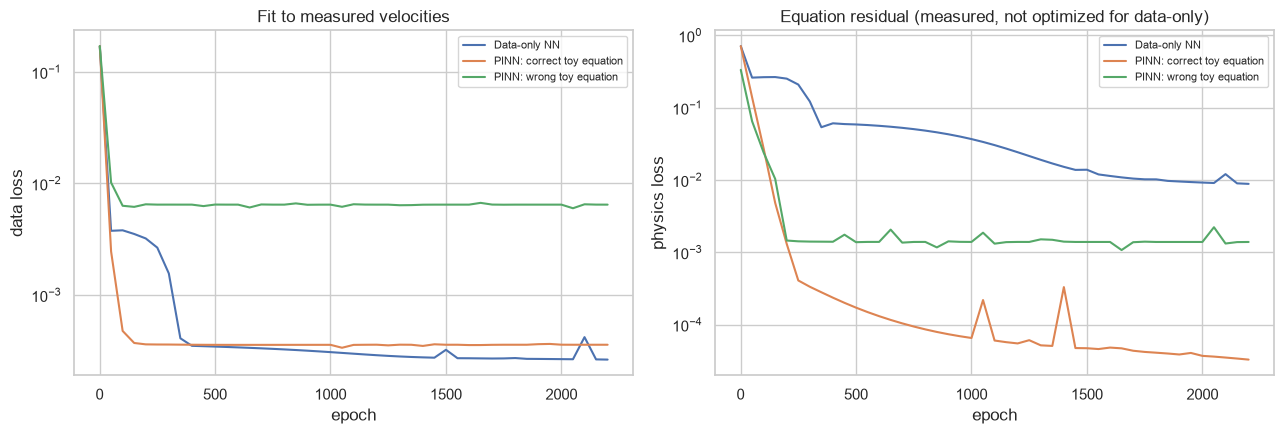

In [6]:
fig,axes=plt.subplots(1,2,figsize=(13,4.5))
for run in runs:
    h=run['history']
    axes[0].semilogy(h.epoch,h.data,label=run['label'])
    axes[1].semilogy(h.epoch,h.physics,label=run['label'])
axes[0].set(title='Fit to measured velocities',xlabel='epoch',ylabel='data loss')
axes[1].set(title='Equation residual (measured, not optimized for data-only)',xlabel='epoch',ylabel='physics loss')
for ax in axes: ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 3. Evaluate on the dense truth
The networks never receive the dense velocity curve. We score the entire interval and the missing-data gap separately.

In [7]:
def predict(model):
    t=torch.tensor(t_dense[:,None],dtype=DTYPE,device=DEVICE,requires_grad=True)
    x=model(t); u=torch.autograd.grad(x,t,torch.ones_like(x))[0]
    return x.detach().cpu().numpy().ravel(), VELOCITY_SCALE*u.detach().cpu().numpy().ravel()

gap=(t_dense>.39)&(t_dense<.68)
rows=[]
for run in runs:
    run['x'],run['v']=predict(run['model'])
    error=run['v']-v_truth
    rows.append({'method':run['label'],'overall_MAE_m/s':np.mean(np.abs(error)),
                 'gap_MAE_m/s':np.mean(np.abs(error[gap])), 'bias_m/s':np.mean(error),
                 'worst_error_m/s':np.max(np.abs(error))})
results=pd.DataFrame(rows).round(2)
results

,method,overall_MAE_m/s,gap_MAE_m/s,bias_m/s,worst_error_m/s
0,Data-only NN,9.08,8.67,-1.34,18.04
1,PINN: correct toy equation,0.80,0.77,-0.79,1.52
2,PINN: wrong toy equation,87.34,150.31,-72.45,170.97


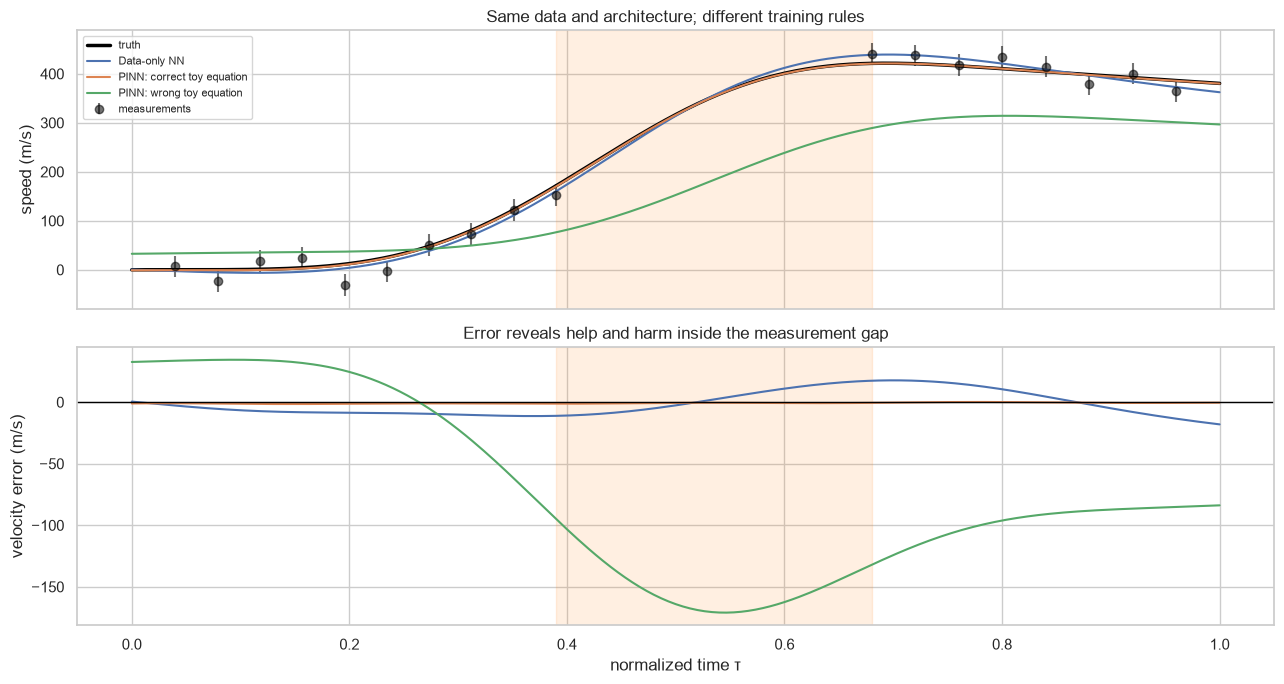

In [8]:
fig,axes=plt.subplots(2,1,figsize=(13,7),sharex=True)
axes[0].plot(t_dense,v_truth,color='black',linewidth=2.5,label='truth')
axes[0].errorbar(measure_t,measure_v,yerr=NOISE_STD,fmt='o',color='black',alpha=.55,label='measurements')
for run in runs: axes[0].plot(t_dense,run['v'],label=run['label'])
axes[0].axvspan(.39,.68,color='tab:orange',alpha=.12); axes[0].set(ylabel='speed (m/s)',title='Same data and architecture; different training rules'); axes[0].legend(fontsize=8)
for run in runs: axes[1].plot(t_dense,run['v']-v_truth,label=run['label'])
axes[1].axhline(0,color='black',linewidth=1); axes[1].axvspan(.39,.68,color='tab:orange',alpha=.12)
axes[1].set(xlabel='normalized time τ',ylabel='velocity error (m/s)',title='Error reveals help and harm inside the measurement gap')
plt.tight_layout(); plt.show()

In [9]:
data_row=results.query("method == 'Data-only NN'").iloc[0]
right_row=results.query("method == 'PINN: correct toy equation'").iloc[0]
wrong_row=results.query("method == 'PINN: wrong toy equation'").iloc[0]
print(f"Correct physics changes gap MAE by {data_row['gap_MAE_m/s']-right_row['gap_MAE_m/s']:+.2f} m/s versus data only.")
print(f"Wrong physics changes gap MAE by {data_row['gap_MAE_m/s']-wrong_row['gap_MAE_m/s']:+.2f} m/s versus data only.")
if wrong_row['gap_MAE_m/s']>data_row['gap_MAE_m/s']:
    print('Negative control worked: the incorrect constraint harmed reconstruction.')
else:
    print('Negative control did not harm this seed; repeat over seeds before interpreting it.')

Correct physics changes gap MAE by +7.90 m/s versus data only.
Wrong physics changes gap MAE by -141.64 m/s versus data only.
Negative control worked: the incorrect constraint harmed reconstruction.


## Where this fits with PDV
Notebook 02 asks: **How do we turn detector voltage into a velocity trace?** A CNN can learn patterns in a spectrogram, while the spectral-ridge baseline explicitly finds the dominant beat frequency.

Notebook 03 asks a downstream question: **Given sparse velocity-like measurements, what continuous motion is consistent with the data and an assumed equation?** This is where a PINN can help.

A future end-to-end physics-informed PDV model could predict position, differentiate it to velocity, convert velocity to beat frequency with `f = 2v/λ`, synthesize detector voltage through a differentiable diagnostic model, and compare that waveform with the recording. It must also represent optical-path drift, multiple returns, calibration, dropout, and model discrepancy. Otherwise the physics loss can force an attractive but false answer.

## Experiments to try
1. Set the physics weight from `1.0` to `0.01`, `0.1`, or `10`. Plot data error versus equation error.
2. Make the measurement gap wider. When does data-only interpolation fail?
3. Increase `NOISE_STD`. Does correct physics help more?
4. Change the wrong equation slightly, then severely. How much misspecification is tolerable?
5. Repeat ten random seeds and report distributions, not one attractive curve.
6. Add a learnable `alpha`. Check whether it is identifiable from the allowed velocity samples.
7. Add a model-discrepancy network or residual term and test whether it detects wrong physics rather than hiding it.